**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 06. MCMC Convergnce Diagnostics
This notebook covers advanced Markov Chain Monte Carlo diagnostic methods. Each test is designed to show convergence behavior and sampling efficiency.

## What You'll Learn
- Multiple chains and convergence diagnostics
- Effective sample size and autocorrelation
- Handling multimodal posteriors
- Hierarchical models
- Sampler tuning and optimization

## Why Convergence Matters

During estimation MCMC samplers:
1. Start from arbitrary initial values
2. Explore parameter space stochastically
3. Eventually converge to target distribution
4. Must discard "burn-in" samples

This process leaves us with some key questions to investigate:
- Have chains converged to stationary distribution?
- How many independent samples do we have?
- Is the warmup period sufficient?

### Theoretical Foundation

The theoretical justification for MCMC rests on the ergodic theorem: under regularity conditions (irreducibility, aperiodicity, positive recurrence), the time average of a function along the Markov chain converges to its expectation under the stationary distribution:

$$
\frac{1}{N}\sum_{t=1}^{N}f(\theta_t) \;\xrightarrow{\;a.s.\;}\; \mathbb{E}_\pi[f(\theta)] \quad \text{as } N \to \infty
$$

where $\pi$ is the target (posterior) distribution. This guarantee is asymptotic -- for any finite $N$, we need diagnostics to assess whether we are close enough to this limit. 

Essentially, this means given enough time a well defined chain will always converge to the posterior. It is our job to ensure the Markov chain has run long enough to do so. We have various tools at our disposal to ensure that we have reached enough iterations for the Markov chain to converge. Only once we have confirmed the chain is performing well, can we draw conclusions about our parameters. 

**Note:** Many code blocks in this notebook have longer run times due to the computationally expensive methods we are testing. Please allow up to 5 minutes of runtime per block before becoming concerned. 

## Set Up

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import time

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Distributions import Normal, Uniform, IUnivariateDistribution
from Numerics.Sampling.MCMC import MCMCSampler, LogLikelihood, RWMH, DEMCz, MCMCResults, MCMCDiagnostics
from Numerics.Data.Statistics import Autocorrelation
from Numerics.Mathematics.LinearAlgebra import Matrix
from helper_functions import convert_to_dotnet_array
from System.Collections.Generic import List

print("✓ Setup complete")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✓ Setup complete


In [2]:
from System.Threading import ThreadPool
import os

''' NOTE FOR DEMO USERS:
When calling Numerics MCMC samplers from Python via pythonnet, the samplers'
internal parallel chains (Parallel.For) contend for Python's Global Interpreter
Lock (GIL). This makes parallel execution slower than sequential. Setting
max thread pool workers to 1 forces sequential execution and removes that
overhead. In pure C#, you can remove this line and parallelism will work as
intended. 

This is also why we set sampler.ParallelizeChains = False for every example.
It defaults to True, which works well in C#, but it slows the sampler down 
in Python'''
ThreadPool.SetMaxThreads(1, 1)  # (workerThreads, completionPortThreads)

# Optional: restore .NET thread pool after demos if needed
# def _restore_dotnet_threadpool():
#     cpu_count = os.cpu_count() or 1
#     ThreadPool.SetMaxThreads(cpu_count, cpu_count)

False

## Helper Functions
The basics of these functions are covered in previous notebooks. We define these here as helper functions to use in the rest of the notebook for efficiency.

In [3]:
def extract_chain_samples(results, param_indx):
    """Extract parameter samples from MCMC sampler."""
    chains = []
    for c in range(len(results.MarkovChains)):
        chain_c = [results.MarkovChains[c][i].Values[param_indx]
                   for i in range(len(results.MarkovChains[c]))]
        chains.append(chain_c)
    return chains

def plot_trace(samples, param_names, title="Trace Plots"):
    """Plot MCMC trace plots."""
    n_params = len(samples)
    fig, axes = plt.subplots(n_params, 1, figsize=(12, 3*n_params))

    if n_params == 1:
        axes = [axes]

    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].plot(sample, linewidth=0.5, alpha=0.7)
        axes[i].set_ylabel(name, fontsize=11)
        axes[i].set_xlabel('Iteration', fontsize=11)
        axes[i].grid(True, alpha=0.3)

        # Add mean line
        axes[i].axhline(np.mean(sample), color='red', linestyle='--',
                       linewidth=2, label=f'Mean: {np.mean(sample):.3f}')
        axes[i].legend(fontsize=9)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

def plot_posterior(samples, param_names, true_values=None, title="Posterior Distributions"):
    """Plot posterior distributions."""
    colors = 'steelblue'
    n_params = len(samples)
    fig, axes = plt.subplots(1, n_params, figsize=(5*n_params, 4))

    if n_params == 1:
        axes = [axes]

    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].hist(sample, bins=50, density=True, alpha=0.7,
                    color=colors)
        axes[i].set_xlabel(name, fontsize=12)
        axes[i].set_ylabel('Density', fontsize=12)
        axes[i].grid(True, alpha=0.3, axis='y')

        if true_values is not None:
            axes[i].axvline(true_values[i], color='red', linestyle='--',
                          linewidth=2, label=f'True: {true_values[i]:.3f}')
            axes[i].legend(fontsize=10)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Multiple Chains for Convergence Assessment
Running multiple chains helps diagnose convergence and assess mixing. We can run diagonsitics on and graph these chains to get a feel on how accurate the posterior is.

Benefits of multiple chains:
1. Assess convergence via R-hat statistic
2. Detect multimodal posteriors
3. Parallelize computation
4. More robust inference

In [4]:
# Generate synthetic data
true_mu = 100
true_sigma = 15
data_net =  Normal(true_mu, true_sigma).GenerateRandomValues(100, 1234)
data = list(data_net)  # Convert to Python list for easier handling

# Define priors
priors = List[IUnivariateDistribution]()
priors.Add(Uniform(50, 150))   # Prior for mu
priors.Add(Uniform(5, 30))     # Prior for sigma

# Log-likelihood function
def log_likelihood(params):
    dist = Normal(params[0], params[1])
    return sum(dist.LogPDF(x) for x in data)

# Convert to .NET Func
log_lik_func = LogLikelihood(log_likelihood)

proposal = Matrix(2, 2)
proposal[0, 0] = 1.0   # variance for mu
proposal[1, 1] = 1.0   # variance for sigma
proposal[0, 1] = 0.0   # covariance
proposal[1, 0] = 0.0

sampler = RWMH(priors, log_lik_func, proposal)
sampler.ParallelizeChains = False
sampler.Initialize = MCMCSampler.InitializationType.Randomize
# Run 4 independent chains (this is also already the default setting in Numerics!)
sampler.NumberOfChains = 4

sampler.Sample()

results = MCMCResults(sampler)

print("✓ RWMH Complete")

✓ RWMH Complete


## R̂ (Gelman-Rubin Statistic)

R̂ (Gelman-Rubin statistic) compares within-chain and between-chain variance [[1]](#1).


| R̂ Value | Interpretation | Action |
|---------|---------------|--------|
| R̂ < 1.01 | Excellent convergence | Proceed |
| R̂ < 1.1 | Good convergence | Safe to use |
| 1.1 ≤ R̂ < 1.2 | Marginal | Run longer |
| R̂ ≥ 1.2 | Poor convergence | Investigate |

### Mathematical Foundation

$$
\hat{R} = \sqrt{\frac{\hat{V}}{W}}
$$
Where $W$ is the mean within-chain variance, $B$ is the between-chain variance, and:
$$
\hat{V} = \frac{n-1}{n}W + \frac{1}{n}B
$$
This is a weighted average that has a key property: $\hat{V}$ overestimates the true target variance when chains have not converged, because $B$ captures the additional spread from chains being in different regions. Meanwhile, $W$ underestimates the true target variance because each finite chain has only explored a portion of the full parameter space. At convergence, the between-chain contribution vanishes ($B/n \to 0$ relative to $W$), and $\hat{V} \to W$.

Since $\hat{V} \geq W$ in general, we have $\hat{R} \geq 1$. At perfect convergence $\hat{R} = 1$; values substantially above 1 indicate that the chains have not mixed and further sampling is needed [[2]](#2).

### Common Causes of High R̂

1. Insufficient warmup: Chains haven't reached stationarity
2. Poor mixing: Chains explore slowly
3. Multimodal posterior: Chains stuck in different modes
4. Bad initialization: Starting values too extreme
5. Wrong sampler: Algorithm not suited to problem

Convergence Diagnostics (R-hat):
μ:     1.0004  ✓ Converged
σ:     1.0003  ✓ Converged


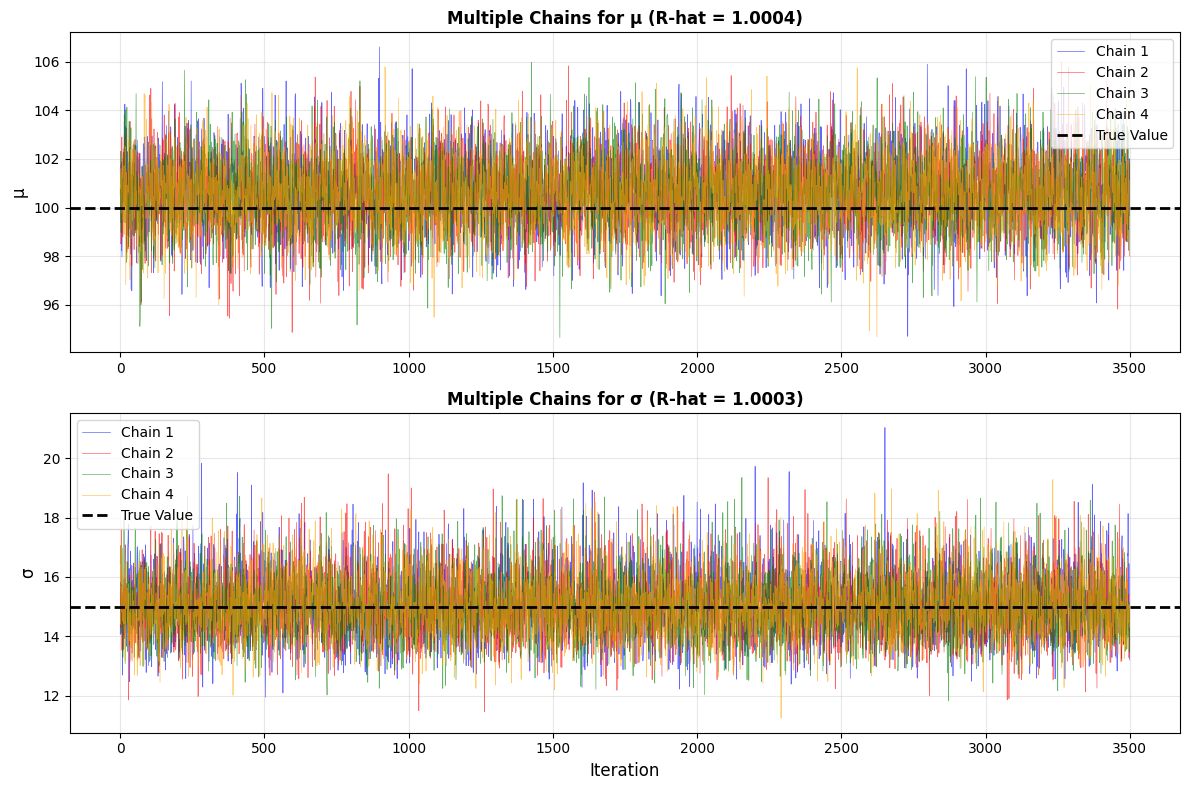

In [5]:
# Extract samples
chains_mu = extract_chain_samples(results, 0)
chains_sigma = extract_chain_samples(results, 1)

# Compute R-hat with Gelman-Rubin from MCMC Diagnostics
markov_chains = results.MarkovChains
rhat = MCMCDiagnostics.GelmanRubin(markov_chains, int(0))
rhat_mu = float(rhat[0])
rhat_sigma = float(rhat[1])

print("Convergence Diagnostics (R-hat):")
print(f"μ:     {rhat_mu:.4f}  {'✓ Converged' if rhat_mu < 1.05 else 'X Not converged'}")
print(f"σ:     {rhat_sigma:.4f}  {'✓ Converged' if rhat_sigma < 1.05 else 'X Not converged'}")

# Plot chains
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

colors = ['blue', 'red', 'green', 'orange']
for i, chain in enumerate(chains_mu):
    axes[0].plot(chain, alpha=0.6, linewidth=0.5, label=f'Chain {i+1}', color=colors[i])
axes[0].axhline(true_mu, color='black', linestyle='--', linewidth=2, label='True Value')
axes[0].set_ylabel('μ', fontsize=12)
axes[0].set_title(f'Multiple Chains for μ (R-hat = {rhat_mu:.4f})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for i, chain in enumerate(chains_sigma):
    axes[1].plot(chain, alpha=0.6, linewidth=0.5, label=f'Chain {i+1}', color=colors[i])
axes[1].axhline(true_sigma, color='black', linestyle='--', linewidth=2, label='True Value')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('σ', fontsize=12)
axes[1].set_title(f'Multiple Chains for σ (R-hat = {rhat_sigma:.4f})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Effective Sample Size (ESS) and Autocorrelation

 The effective sample size (ESS) is defined as the number of independent samples that would give the same variance for the sample mean [[3]](#3). A higher ESS is better. Moreover, ESS is highly tied to autocorrelation.

Guidelines:
- ESS > 400: Excellent - precise estimates
- ESS > 100: Good - adequate for most purposes
- ESS < 100: Poor - increase iterations or improve mixing

Impact of autocorrelation on ESS:
- High autocorrelation → Low ESS → Need more iterations
- Good mixing → High ESS → Efficient sampling

### Mathematical Foundation
The formula for ESS is as follows 
$$
\text{ESS} = \frac{N}{1 + 2\sum_{k=1}^{K} \rho_k}
$$
where $N$ is the number of samples, $\rho_k$ is the autocorrelation at lag $k$, and the sum is truncated when $\rho_k$ becomes negligible. The quantity $\tau = 1 + 2\sum_{k=1}^{\infty}\rho_k$ is called the integrated autocorrelation time. It represents how many MCMC iterations correspond to one independent draw: $\text{ESS} = N/\tau$.


Multi-chain ESS: When $M$ chains of length $N$ are available, the implementation computes the autocorrelation sum $\rho_m$ for each chain $m$ separately, then averages across chains:

$$
\bar{\rho} = \frac{1}{M}\sum_{m=1}^{M}\rho_m \qquad \text{where} \quad \rho_m = \sum_{k=1}^{K_m}\hat{\rho}_k^{(m)}
$$

Here $K_m$ is the truncation point for chain $m$ (the first lag at which the autocorrelation is negative). The total effective sample size is then:

$$
\text{ESS} = \frac{N \cdot M}{1 + 2\bar{\rho}}
$$

This is capped at $N \cdot M$ (the total number of samples) since the effective sample size cannot exceed the actual number of draws.

### ESS Requirements

The minimum ESS needed depends on what posterior summary you are estimating:

| Inference Goal | Minimum ESS | Rationale |
|---------------|------------|-----------|
| Posterior mean | 100 | MCSE is approximately 10% of posterior SD |
| Posterior standard deviation | 200 | Variance estimation requires more samples than mean estimation |
| 95% credible interval | 400 | Quantile estimation demands greater precision in the tails |
| Tail probabilities (e.g., $P(\theta > c)$) | 1000+ | Extreme quantiles are estimated from sparse tail samples |

These thresholds are guidelines, not strict rules. For life-safety applications, err on the side of larger ESS.

### Autocorrelation Guidelines

| Lag-1 ACF | Interpretation | ESS Impact |
|-----------|---------------|------------|
| < 0.1 | Excellent mixing | ESS ≈ N |
| 0.1-0.3 | Good mixing | ESS ≈ 0.5N |
| 0.3-0.6 | Moderate | ESS ≈ 0.2N |
| > 0.6 | Poor mixing | ESS << 0.1N |

Effective Sample Size


,Metric,Value
0,Total samples,14000.00
1,ESS (μ),11052.62
2,ESS efficiency (μ),78.95
3,ESS (σ),12431.72
4,ESS efficiency (σ),88.80


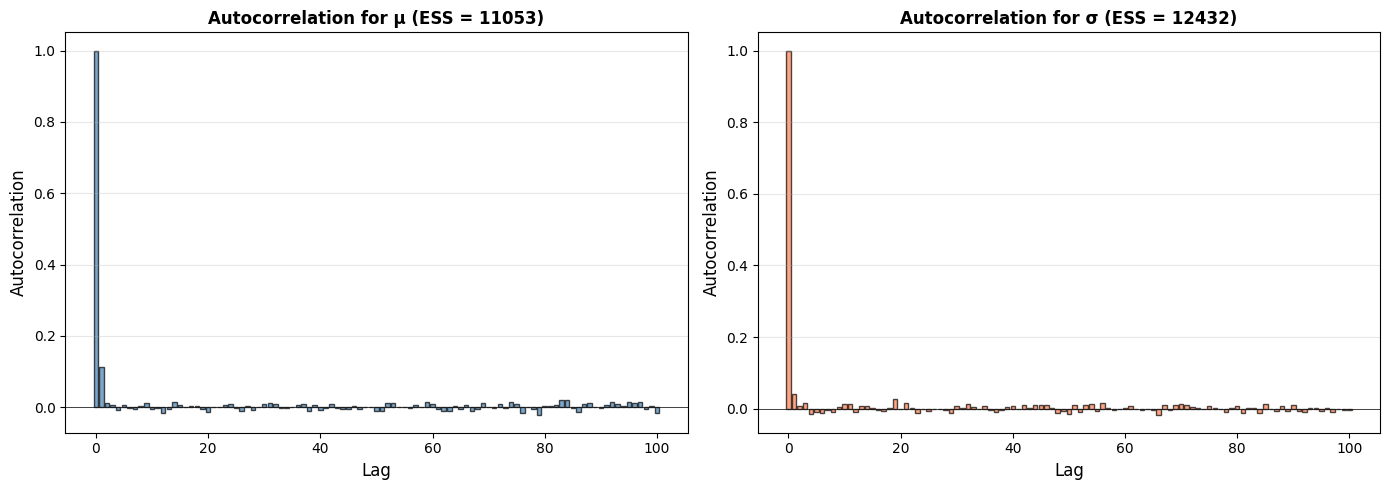

In [6]:
# Combine all chains
combined_mu = np.asarray(np.concatenate(chains_mu), dtype=float)
combined_sigma = np.asarray(np.concatenate(chains_sigma), dtype=float)

# ESS with Numerics
ess_mu = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_mu)))
ess_sigma = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_sigma)))

ess_df = pd.DataFrame(
    {
        'Metric': ['Total samples', 'ESS (μ)', 'ESS efficiency (μ)', 'ESS (σ)', 'ESS efficiency (σ)'],
        'Value': [len(combined_mu), ess_mu, 100 * ess_mu / len(combined_mu), ess_sigma, 100 * ess_sigma / len(combined_sigma)],
    }
)
print("Effective Sample Size")
display(ess_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_lag = 100

# Autocorrelation from Numerics
acf_mu = Autocorrelation.Function(
    convert_to_dotnet_array(combined_mu),
    int(max_lag),
    Autocorrelation.Type.Correlation,
)
acf_sigma = Autocorrelation.Function(
    convert_to_dotnet_array(combined_sigma),
    int(max_lag),
    Autocorrelation.Type.Correlation,
)

lags_mu = np.array([int(acf_mu[i, 0]) for i in range(acf_mu.GetLength(0))], dtype=int)
autocorr_mu = np.array([float(acf_mu[i, 1]) for i in range(acf_mu.GetLength(0))], dtype=float)

lags_sigma = np.array([int(acf_sigma[i, 0]) for i in range(acf_sigma.GetLength(0))], dtype=int)
autocorr_sigma = np.array([float(acf_sigma[i, 1]) for i in range(acf_sigma.GetLength(0))], dtype=float)

axes[0].bar(lags_mu, autocorr_mu, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Lag', fontsize=12)
axes[0].set_ylabel('Autocorrelation', fontsize=12)
axes[0].set_title(f'Autocorrelation for μ (ESS = {ess_mu:.0f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(lags_sigma, autocorr_sigma, alpha=0.7, color='coral', edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Lag', fontsize=12)
axes[1].set_ylabel('Autocorrelation', fontsize=12)
axes[1].set_title(f'Autocorrelation for σ (ESS = {ess_sigma:.0f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Handling Multimodal Posteriors

Some posteriors can have multiple peaks. DEMCz and DEMCzs are better at exploring these.

Fitting mixture model with DEMCz...

Mixture Model Estimates:


,Parameter,Mean,Weight
0,μ1,98.48,0.5
1,σ1,10.93,0.5
2,μ2,100.51,0.5
3,σ2,10.87,0.5


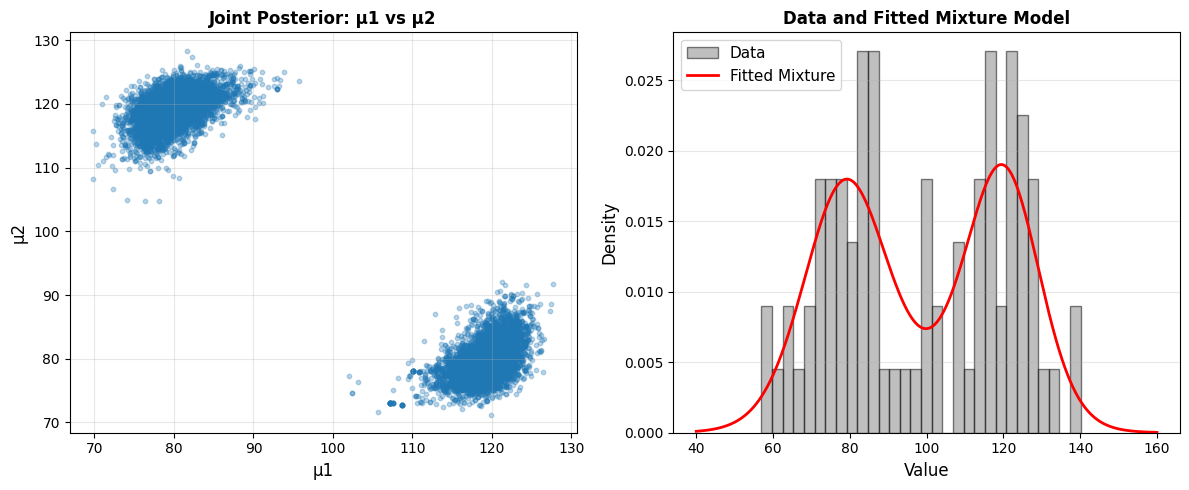

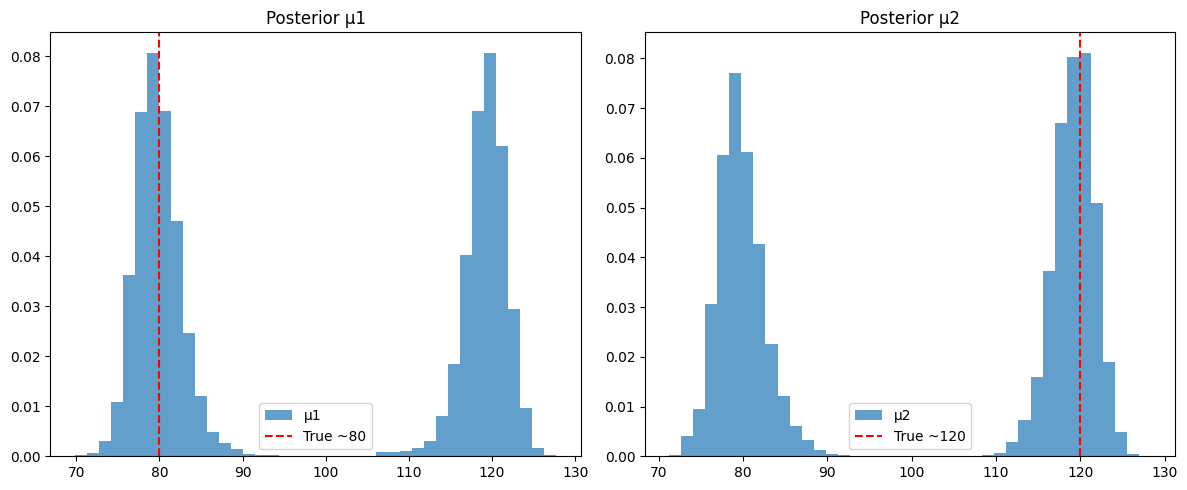

In [7]:
# Create bimodal mixture data
np.random.seed(789)
mode1 = Normal(80, 10).GenerateRandomValues(40, 789)
mode2 = Normal(120, 10).GenerateRandomValues(40, 789)
bimodal_data = np.concatenate([list(mode1), list(mode2)])
bimodal_net = convert_to_dotnet_array(bimodal_data)

# Priors for mixture model
priors_mixture = List[IUnivariateDistribution]()
priors_mixture.Add(Uniform(50, 150))   # mu1
priors_mixture.Add(Uniform(5, 20))     # sigma1
priors_mixture.Add(Uniform(50, 150))   # mu2
priors_mixture.Add(Uniform(5, 20))     # sigma2
priors_mixture.Add(Uniform(0.01, 0.99))  # weight

# Mixture model log-likelihood
def log_lik_mixture(params):
    mu1, sigma1, mu2, sigma2, weight = params[0], params[1], params[2], params[3], params[4]
    
    dist1 = Normal(mu1, sigma1)
    dist2 = Normal(mu2, sigma2)
    
    total_ll = 0
    for x in bimodal_data:
        prob = weight * np.exp(dist1.LogPDF(x)) + (1 - weight) * np.exp(dist2.LogPDF(x))
        if prob > 0:
            total_ll += np.log(prob)
        else:
            total_ll += -1e10
    
    return total_ll

log_lik_mixture_func = LogLikelihood(log_lik_mixture)

# Use DEMCz for multimodal posterior
print("Fitting mixture model with DEMCz...")
demcz = DEMCz(priors_mixture, log_lik_mixture_func)
demcz.ParallelizeChains = False
demcz.BurnIn = 3000
demcz.SampleSize = 10000

demcz.Sample()
results = MCMCResults(demcz)

mu1_chains = extract_chain_samples(results, 0)
sigma1_chains = extract_chain_samples(results, 1)
mu2_chains = extract_chain_samples(results, 2)
sigma2_chains = extract_chain_samples(results, 3)
weight_chains = extract_chain_samples(results, 4)

mu1_samples = np.concatenate(mu1_chains)
sigma1_samples = np.concatenate(sigma1_chains)
mu2_samples = np.concatenate(mu2_chains)
sigma2_samples = np.concatenate(sigma2_chains)
weight_samples = np.concatenate(weight_chains)

print("\nMixture Model Estimates:")
summary_table = pd.DataFrame({
    'Parameter': ['μ1', 'σ1', 'μ2', 'σ2'],
    'Mean': [np.mean(mu1_samples), np.mean(sigma1_samples), np.mean(mu2_samples), np.mean(sigma2_samples)],
    'Weight': np.mean(weight_samples)
})
display(summary_table.round(2))

# Joint posterior plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(mu1_samples, mu2_samples, alpha=0.3, s=10)
plt.xlabel('μ1', fontsize=12)
plt.ylabel('μ2', fontsize=12)
plt.title('Joint Posterior: μ1 vs μ2', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(bimodal_data, bins=30, density=True, alpha=0.5, color='gray', 
         edgecolor='black', label='Data')
x_range = np.linspace(40, 160, 500)
mean_weight = np.mean(weight_samples)


# Use a subset of posterior samples to approximate posterior predictive
idx = np.random.choice(len(mu1_samples), size=min(1000, len(mu1_samples)), replace=False)

pdf_mixture = []
for x in x_range:
    vals = []
    for j in idx:
        d1 = Normal(mu1_samples[j], sigma1_samples[j])
        d2 = Normal(mu2_samples[j], sigma2_samples[j])
        vals.append(weight_samples[j] * d1.PDF(x) + (1 - weight_samples[j]) * d2.PDF(x))
    pdf_mixture.append(np.mean(vals))

plt.plot(x_range, pdf_mixture, 'r-', linewidth=2, label='Fitted Mixture')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Data and Fitted Mixture Model', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Marginal posterior plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(mu1_samples, bins=40, alpha=0.7, density=True, label='μ1')
plt.axvline(80, color='red', linestyle='--', label='True ~80')
plt.legend(); plt.title('Posterior μ1')

plt.subplot(1,2,2)
plt.hist(mu2_samples, bins=40, alpha=0.7, density=True, label='μ2')
plt.axvline(120, color='red', linestyle='--', label='True ~120')
plt.legend(); plt.title('Posterior μ2')

plt.tight_layout()
plt.show()


## Tuning Tips and Best Practices

### General Guidelines

1. Burn-in: Use 10-50% of total iterations
2. Sample size: At least 1000 effective samples
3. Multiple chains: Run 3-4 chains to assess convergence
4. Thinning: Usually not necessary with modern samplers

### Troubleshooting
- High R̂ (> 1.1)?
    - Increase warmup
    - Try a different sampler
    - Check initialization
- Low ESS (<100)?
    - Increase iterations
    - Increase thinning
    - Improve sampler (i.e. use ARWMH vs RWMH)
- Mulitmodal Posterior?
    - Use population-based sampler
    - Check for model identification issues
    - Consider transforming parameters

## Summary

You've learned:

$\checkmark$ Running multiple chains for convergence diagnostics      
$\checkmark$ Computing R-hat and ESS      
$\checkmark$ Handling multimodal posteriors with DEMCz        
$\checkmark$ Best practices for MCMC      

## Key Takeaways

1. Always check convergence → Use R-hat and visual inspection
2. ESS matters more than raw samples → Account for autocorrelation
3. Different samplers for different problems → No one-size-fits-all
4. Adaptive methods reduce tuning burden → ARWMH, DEMCz are robust
5. Multiple chains catch problems early → Run at least 3-4 chains

## Exercise

1. Generate data from a Gamma distribution
2. Fit using 3 different MCMC samplers
3. Compare ESS and convergence
4. Which sampler performs best?

## References

<a id="1">[1]</a> A. Gelman and D. B. Rubin, "Inference from iterative simulation using multiple sequences," *Statistical Science*, vol. 7, no. 4, pp. 457-472, 1992.

<a id="2">[2]</a> A. Vehtari, A. Gelman, D. Simpson, B. Carpenter, and P.-C. Burkner, "Rank-normalization, folding, and localization: An improved R-hat for assessing convergence of MCMC," *Bayesian Analysis*, vol. 16, no. 2, pp. 667-718, 2021.

<a id="3">[3]</a> C. J. Geyer, "Practical Markov chain Monte Carlo," *Statistical Science*, vol. 7, no. 4, pp. 473-483, 1992.
